# The Central Limit Theorem

## Learning Objectives

By the end of this notebook you will be able to:

1. State the **Central Limit Theorem** (CLT) precisely.
2. Explain **why** the Normal distribution appears everywhere in statistics.
3. Demonstrate the CLT empirically by simulating sample means from non-Normal distributions.
4. Apply the CLT to approximate probabilities involving sums and averages.
5. Understand the conditions under which the CLT does (and does not) apply.

## Prerequisites

- [01_discrete_distributions.ipynb](01_discrete_distributions.ipynb) — Binomial
- [02_continuous_distributions.ipynb](02_continuous_distributions.ipynb) — Normal distribution, PDF
- [Module 01, notebook 06](../01_probability_basics/06_inequalities.ipynb) — weak LLN (the CLT is a much stronger result)

In [1]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)
        if not self.has_latex:
            print("⚠ LaTeX not found — MathTex will fall back to Text().")

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. Why Does the Normal Distribution Appear Everywhere?

In the previous notebook we introduced the Normal distribution and saw it has a beautiful bell-shaped PDF. But why does it deserve its name? Why is it "normal"?

The answer is one of the deepest results in probability theory: the **Central Limit Theorem**. It says that whenever you **average** many independent random contributions — regardless of their individual distribution — the result is approximately Normal.

This explains why:
- Human heights are approximately Normal (determined by many genes + environmental factors)
- Measurement errors are approximately Normal (sum of many small disturbances)
- Stock returns are approximately Normal over short horizons (sum of many trades)
- The Binomial looks Normal for large $n$ (sum of many Bernoulli trials)

---

## 2. The Theorem

> **Theorem (Central Limit Theorem).** Let $X_1, X_2, \dots, X_n$ be independent, identically distributed (i.i.d.) random variables with mean $\mu$ and finite variance $\sigma^2 > 0$. Define the standardised sample mean:
>
> $$Z_n = \frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} \quad \text{where} \quad \bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i$$
>
> Then as $n \to \infty$:
>
> $$Z_n \xrightarrow{d} \mathcal{N}(0, 1)$$

In practical terms: for large enough $n$,

$$\bar{X}_n \approx \mathcal{N}\!\left(\mu,\; \frac{\sigma^2}{n}\right)$$

### What the CLT does NOT say

- It does **not** say individual $X_i$ are Normal — they can be anything (uniform, exponential, discrete, skewed...).
- It requires **finite variance** — distributions with infinite variance (like the Cauchy) are excluded.
- It's an **asymptotic** result — it tells us what happens as $n \to \infty$, not how large $n$ needs to be. In practice, $n \geq 30$ is a common rule of thumb, but skewed distributions need larger $n$.

### Comparison with the LLN

| Result              | What it says                                                              | Strength                                |
|---------------------|---------------------------------------------------------------------------|-----------------------------------------|
| **LLN** (Module 01) | $\bar{X}_n \to \mu$ (converges to a number)                               | The mean converges                      |
| **CLT**             | $\bar{X}_n \approx \mathcal{N}(\mu, \sigma^2/n)$ (gives the distribution) | We know the *shape* of the fluctuations |

---

## 3. Seeing the CLT in Action

To understand the CLT concretely, let's walk through exactly what it claims. Consider the $\text{Exponential}(1)$ distribution — a right-skewed distribution with $\mu = 1$ and $\sigma^2 = 1$, which looks nothing like a Normal.

The CLT says: if we repeatedly **draw a sample** of size $n$ from this distribution and compute the **sample mean** $\bar{X}_n$, then the *distribution of those sample means* will approach a Normal — even though the individual values are Exponential.

The process is:
1. Draw $n$ values from the parent distribution.
2. Compute their mean $\bar{X}_n$.
3. Repeat many times.
4. Plot the histogram of the $\bar{X}_n$ values.

The first plot below shows this process: the parent distribution on the left, a few samples drawn from it in the middle, and the resulting distribution of sample means on the right.

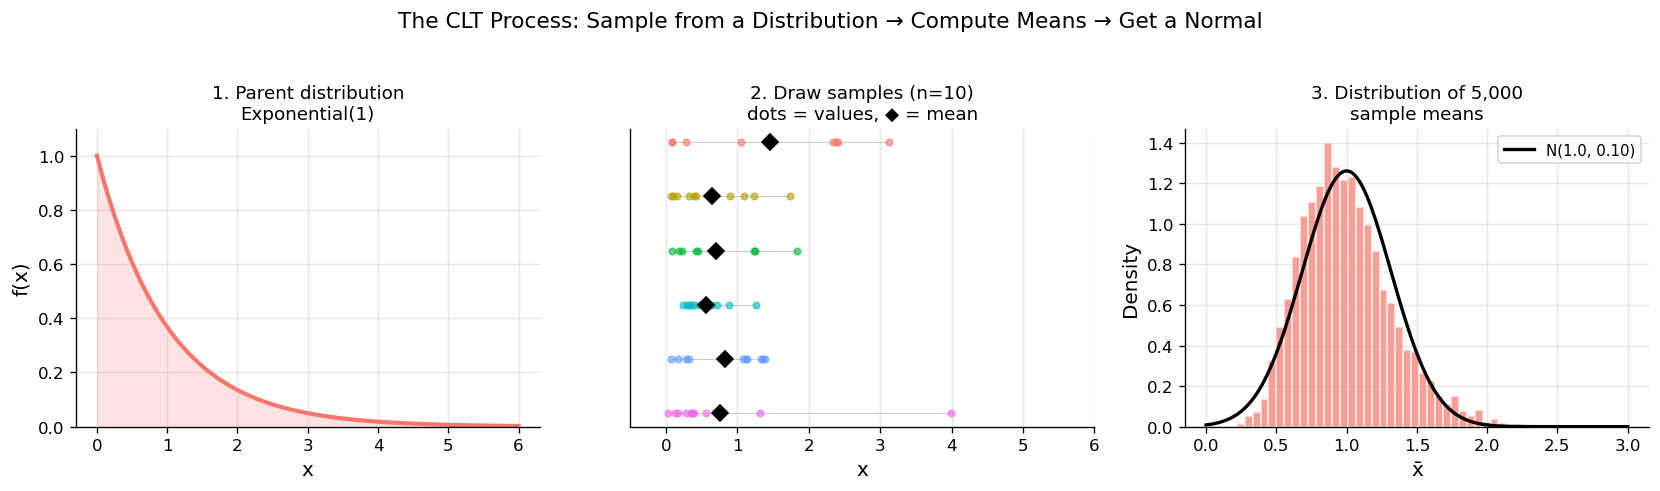

In [ ]:
# Step-by-step: parent distribution → draw samples → compute means → histogram
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
rng_demo = np.random.default_rng(42)
n_sample = 10

# Panel 1: the parent distribution
x = np.linspace(0, 6, 200)
axes[0].plot(x, stats.expon.pdf(x), linewidth=2.5)
axes[0].fill_between(x, stats.expon.pdf(x), alpha=0.2)
axes[0].set_title("1. Parent distribution\nExponential(1)", fontsize=11)
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].set_ylim(0, 1.1)

# Panel 2: draw a few samples of size n, show individual values + their means
for i in range(6):
    sample = rng_demo.exponential(1, size=n_sample)
    y_pos = 5 - i * 0.8
    axes[1].scatter(sample, [y_pos] * n_sample, s=15, alpha=0.6, zorder=3)
    mean_val = sample.mean()
    axes[1].plot(mean_val, y_pos, "D", color="black", markersize=7, zorder=4)
    axes[1].hlines(
        y_pos, sample.min(), sample.max(), color="grey", linewidth=0.5, alpha=0.5
    )

axes[1].set_title(
    f"2. Draw samples (n={n_sample})\ndots = values, ◆ = mean", fontsize=11
)
axes[1].set_xlabel("x")
axes[1].set_yticks([])
axes[1].set_xlim(-0.5, 6)

# Panel 3: histogram of 5000 sample means
means = np.array([rng_demo.exponential(1, n_sample).mean() for _ in range(5000)])
axes[2].hist(means, bins=40, density=True, alpha=0.7, edgecolor="white")
# Normal overlay
mu_theory, sig_theory = 1.0, 1.0 / np.sqrt(n_sample)
x_norm = np.linspace(0, 3, 200)
axes[2].plot(
    x_norm,
    stats.norm(mu_theory, sig_theory).pdf(x_norm),
    "k-",
    linewidth=2,
    label=f"N({mu_theory}, {sig_theory**2:.2f})",
)
axes[2].set_title("3. Distribution of 5,000\nsample means", fontsize=11)
axes[2].set_xlabel("x̄")
axes[2].set_ylabel("Density")
axes[2].legend(fontsize=9)

plt.suptitle(
    "The CLT Process: Sample from a Distribution → Compute Means → Get a Normal",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

Individual Exponential values (panel 1) are heavily right-skewed. But each sample mean (the diamonds in panel 2) is already more centred than any single draw. Collect thousands of these means (panel 3) and the histogram is approximately Normal — even though the parent distribution is far from it.

The critical question is: **how does the convergence depend on $n$?** The plot below shows the distribution of sample means for increasing sample sizes, all drawn from the same Exponential parent.

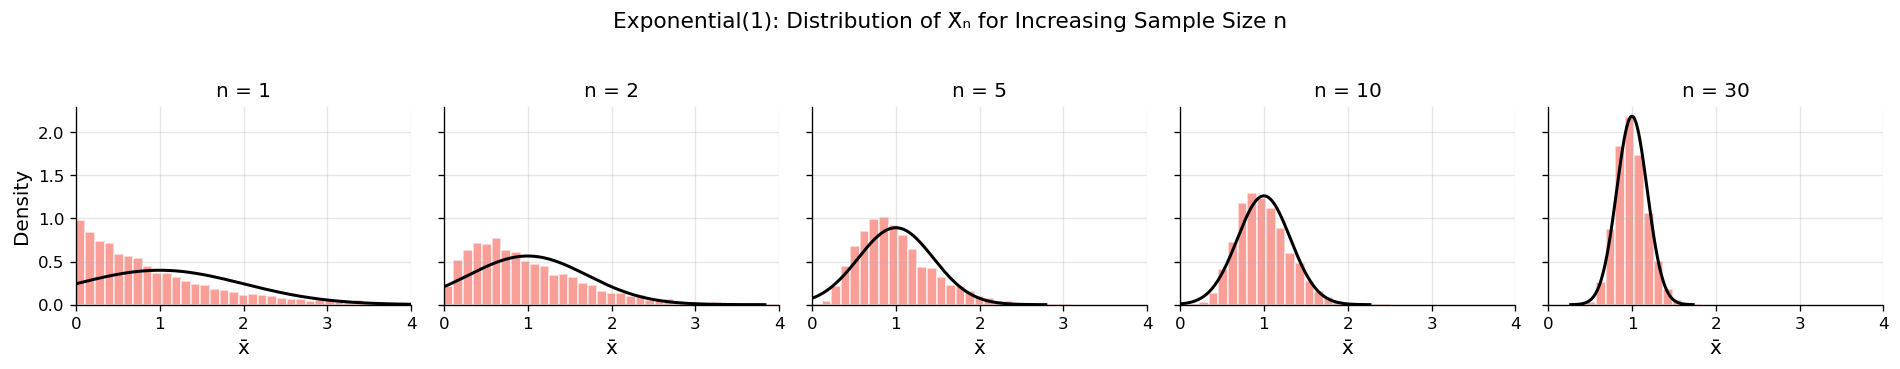

In [ ]:
# How the distribution of sample means changes with n
fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=True)

rng_conv = np.random.default_rng(42)
n_means = 5000
sample_sizes = [1, 2, 5, 10, 30]

for ax, n in zip(axes, sample_sizes):
    means = np.array([rng_conv.exponential(1, n).mean() for _ in range(n_means)])
    ax.hist(means, bins=35, density=True, alpha=0.7, edgecolor="white", range=(0, 4))

    # Normal overlay
    mu_t, sig_t = 1.0, 1.0 / np.sqrt(n)
    x_t = np.linspace(max(0.01, mu_t - 4 * sig_t), mu_t + 4 * sig_t, 200)
    ax.plot(x_t, stats.norm(mu_t, sig_t).pdf(x_t), "k-", linewidth=1.8)

    ax.set_title(f"n = {n}", fontsize=12)
    ax.set_xlabel("x̄")
    ax.set_xlim(0, 4)

axes[0].set_ylabel("Density")
plt.suptitle(
    "Exponential(1): Distribution of X̄ₙ for Increasing Sample Size n",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

At $n = 1$ we just see the Exponential shape. By $n = 5$ the skew is largely gone. By $n = 30$ the Normal fit (black curve) is nearly perfect. The convergence is gradual — the animation below shows this transition in motion for the same Exponential(1) parent.

In [4]:
from manim import *

cfg.apply_manim_config()
math_text = cfg.math_text

from amstats.manim_utils import C

Manim Community v0.18.1

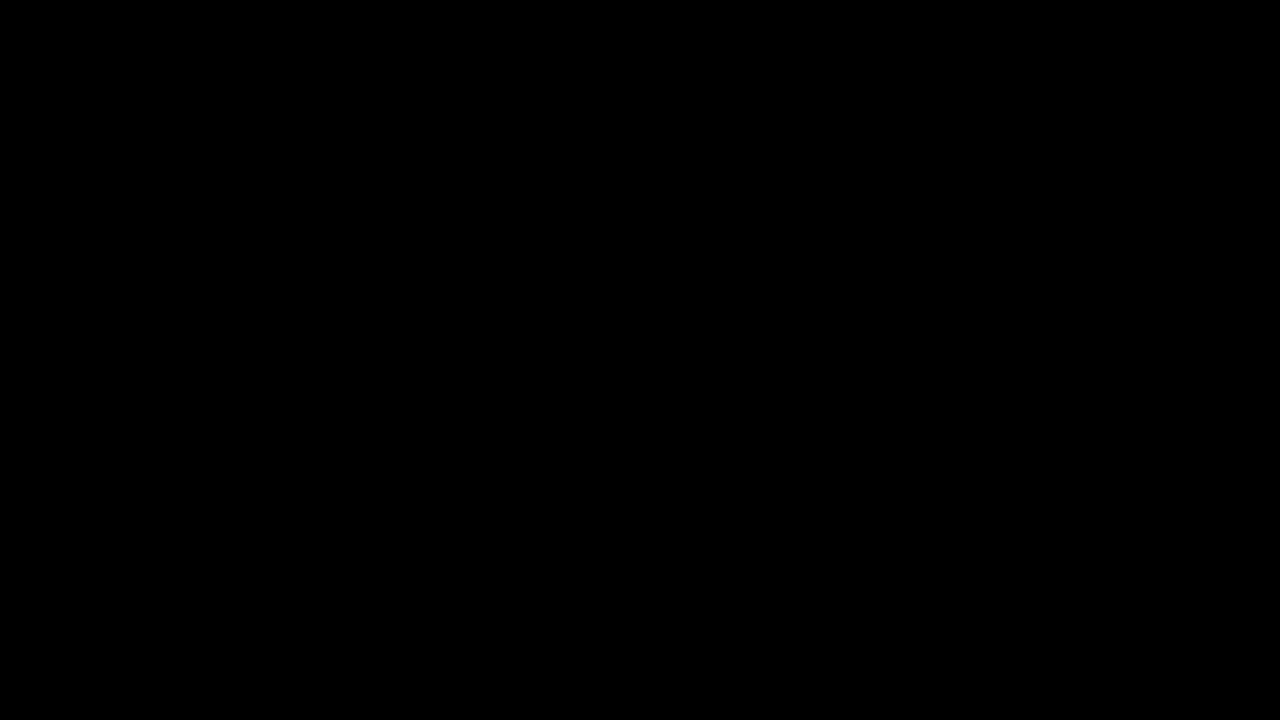

In [ ]:
%%manim -qm -v WARNING CLTConvergence


class CLTConvergence(Scene):
    """Animate sample-mean histograms converging to Normal as n grows."""

    def construct(self):
        title = Text(
            "Central Limit Theorem: Exponential(1) → Normal", font_size=26
        ).to_edge(UP)
        self.play(Write(title))

        rng_local = np.random.default_rng(42)
        n_means = 5000

        axes = Axes(
            x_range=[-3, 5, 1],
            y_range=[0, 1.2, 0.2],
            x_length=9,
            y_length=4,
            axis_config={"include_numbers": True, "font_size": 18},
        ).shift(DOWN * 0.5)
        x_lbl = axes.get_x_axis_label(
            Text("x̄", font_size=20), edge=DOWN, direction=DOWN
        )
        self.play(Create(axes), Write(x_lbl), run_time=0.8)

        sample_sizes = [1, 2, 5, 10, 30]
        prev_bars = None
        prev_curve = None
        prev_label = None

        for n in sample_sizes:
            # Generate sample means
            means = np.array(
                [rng_local.exponential(1.0, size=n).mean() for _ in range(n_means)]
            )

            # Build histogram bars
            counts, bin_edges = np.histogram(
                means, bins=40, range=(-1, 5), density=True
            )
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            bar_w = bin_edges[1] - bin_edges[0]

            bars = VGroup()
            for cx, cy in zip(bin_centers, counts):
                if cy < 0.001:
                    continue
                h = cy * (4 / 1.2)
                bar = Rectangle(
                    width=bar_w * (9 / 8),
                    height=max(h, 0.01),
                    fill_color=C.PERIWINKLE,
                    fill_opacity=0.6,
                    stroke_width=0.5,
                    stroke_color=WHITE,
                ).move_to(axes.c2p(cx, cy / 2))
                bars.add(bar)

            # Theoretical Normal overlay
            mu, sigma = 1.0, 1.0 / np.sqrt(n)  # Exp(1): mean=1, var=1
            normal_curve = axes.plot(
                lambda x, m=mu, s=sigma: (
                    (1 / (s * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - m) / s) ** 2)
                ),
                x_range=[max(-1, mu - 4 * sigma), min(5, mu + 4 * sigma)],
                color=C.SALMON,
                stroke_width=3,
            )

            n_label = math_text(rf"n = {n}", font_size=28, color=C.GOLD).to_corner(UR)

            if prev_bars is None:
                self.play(
                    FadeIn(bars), Create(normal_curve), Write(n_label), run_time=1
                )
                prev_bars = bars
                prev_curve = normal_curve
                prev_label = n_label
            else:
                self.play(
                    Transform(prev_bars, bars),
                    Transform(prev_curve, normal_curve),
                    Transform(prev_label, n_label),
                    run_time=1.2,
                )
            self.wait(0.8)

        self.wait(1.5)

At $n = 1$ the distribution of $\bar{X}$ is just the Exponential itself — sharply right-skewed. By $n = 5$ it's already becoming symmetric. By $n = 30$ the histogram matches the Normal curve almost perfectly. **This is the CLT.**

---

## 4. CLT Across Multiple Parent Distributions

The CLT works regardless of the parent distribution — as long as it has finite variance. Let's verify this with three very different distributions: Exponential (skewed), Uniform (flat), and Bernoulli (discrete).

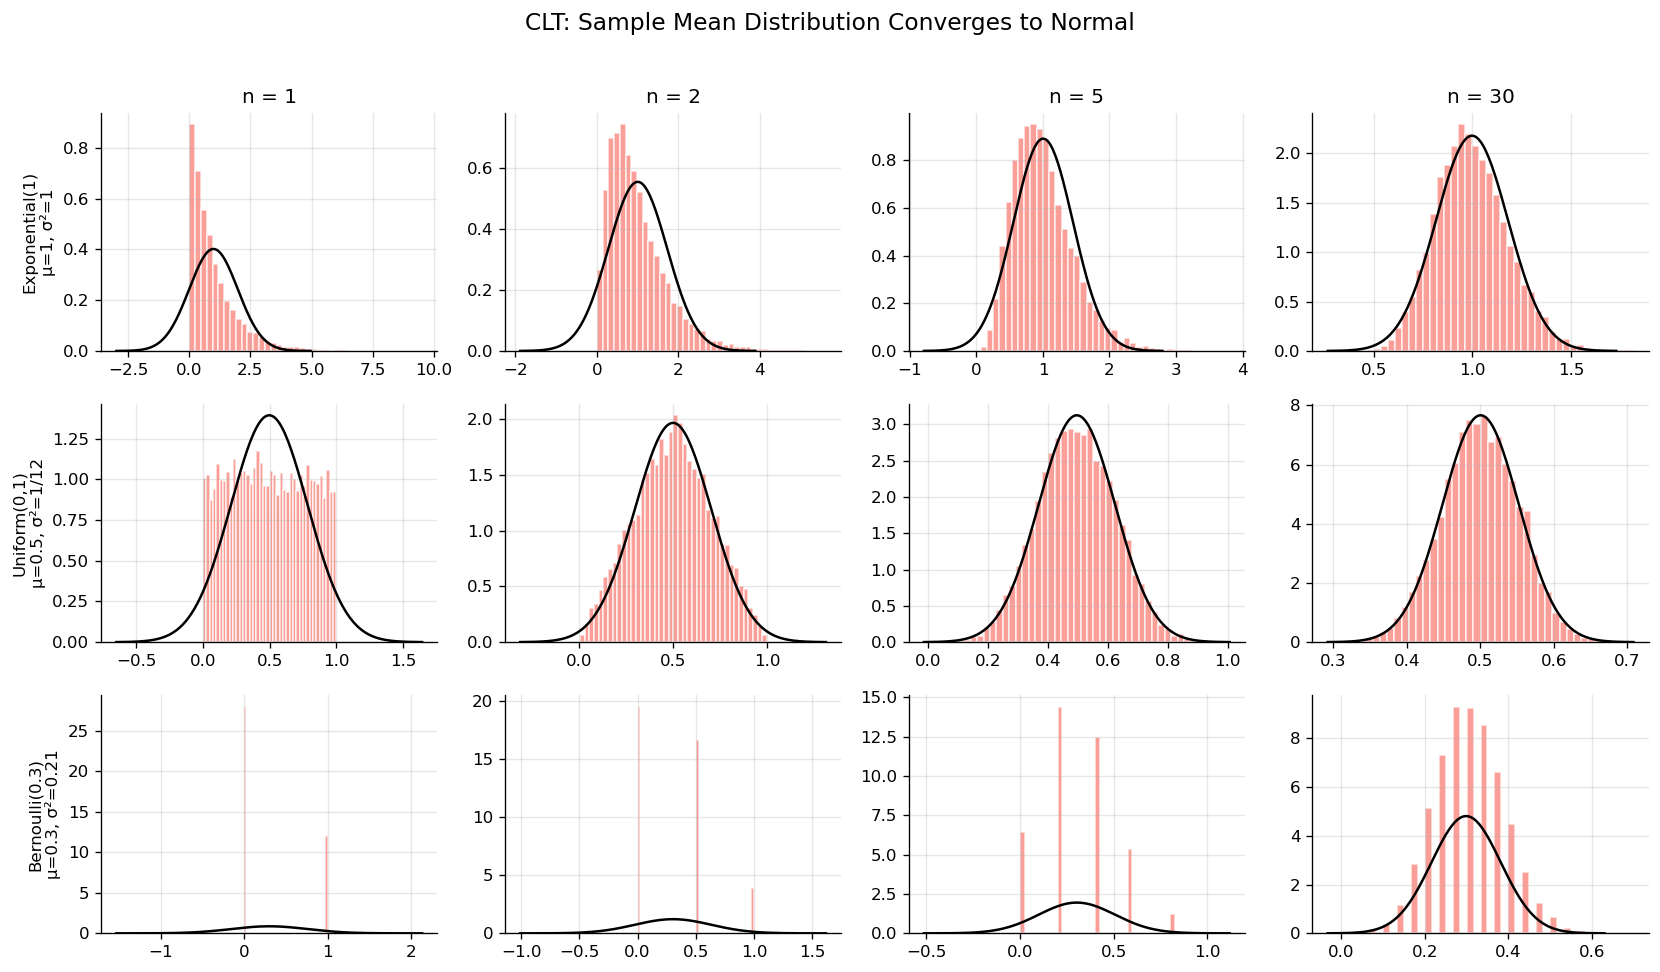

In [5]:
# CLT demonstration: three parent distributions, increasing n
distributions = {
    "Exponential(1)\nμ=1, σ²=1": lambda size: rng.exponential(1, size),
    "Uniform(0,1)\nμ=0.5, σ²=1/12": lambda size: rng.uniform(0, 1, size),
    "Bernoulli(0.3)\nμ=0.3, σ²=0.21": lambda size: rng.binomial(1, 0.3, size),
}

n_means = 10_000
sample_sizes = [1, 2, 5, 30]

fig, axes = plt.subplots(
    len(distributions), len(sample_sizes), figsize=(14, 8), sharex=False, sharey=False
)

for row, (name, sampler) in enumerate(distributions.items()):
    for col, n in enumerate(sample_sizes):
        means = np.array([sampler(n).mean() for _ in range(n_means)])
        ax = axes[row, col]
        ax.hist(means, bins=40, density=True, alpha=0.7, edgecolor="white")

        # Overlay theoretical Normal
        mu_hat = means.mean()
        sig_hat = means.std()
        x = np.linspace(mu_hat - 4 * sig_hat, mu_hat + 4 * sig_hat, 200)
        ax.plot(x, stats.norm(mu_hat, sig_hat).pdf(x), "k-", linewidth=1.5)

        if row == 0:
            ax.set_title(f"n = {n}", fontsize=12)
        if col == 0:
            ax.set_ylabel(name, fontsize=10)

plt.suptitle("CLT: Sample Mean Distribution Converges to Normal", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Left column ($n = 1$):** each histogram looks like the parent distribution itself. **Right column ($n = 30$):** all three are approximately Normal, despite starting from very different shapes. The black curve is the Normal density with matching mean and variance — the fit improves with $n$.

---

## 5. Practical Application: Normal Approximation to the Binomial

One of the most common applications of the CLT: since $X \sim \text{Binomial}(n, p)$ is a sum of $n$ independent Bernoulli trials, for large $n$:

$$X \approx \mathcal{N}(np,\; np(1-p))$$

This lets us approximate Binomial probabilities using the Normal CDF $\Phi$ instead of summing many terms of $\binom{n}{k} p^k (1-p)^{n-k}$.

### Example

A fair coin is flipped 100 times. What is $P(45 \leq X \leq 55)$?

P(45 ≤ X ≤ 55) for Binomial(100, 0.5):
  Exact (Binomial):  0.728747
  CLT approx:        0.728668
  Error:             0.000079


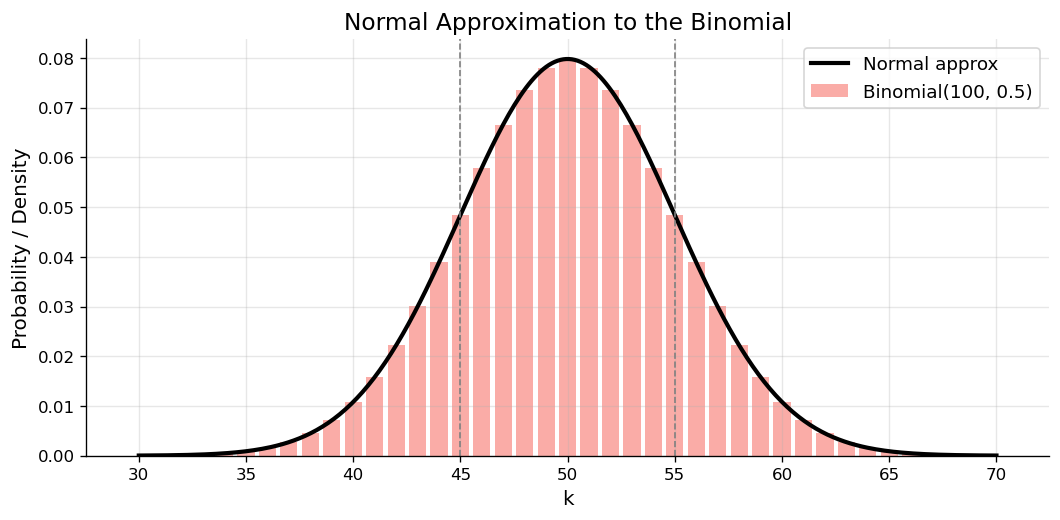

In [6]:
# Normal approximation to Binomial(100, 0.5)
n, p = 100, 0.5
mu = n * p  # 50
sigma = np.sqrt(n * p * (1 - p))  # 5

# Exact (Binomial)
exact = stats.binom(n, p).cdf(55) - stats.binom(n, p).cdf(44)

# CLT approximation (with continuity correction)
approx = stats.norm(mu, sigma).cdf(55.5) - stats.norm(mu, sigma).cdf(44.5)

print(f"P(45 ≤ X ≤ 55) for Binomial(100, 0.5):")
print(f"  Exact (Binomial):  {exact:.6f}")
print(f"  CLT approx:        {approx:.6f}")
print(f"  Error:             {abs(exact - approx):.6f}")

# Visualise the approximation
fig, ax = plt.subplots(figsize=(9, 4.5))
ks = np.arange(30, 71)
ax.bar(ks, stats.binom(n, p).pmf(ks), width=0.8, alpha=0.6, label="Binomial(100, 0.5)")

x = np.linspace(30, 70, 300)
ax.plot(x, stats.norm(mu, sigma).pdf(x), "k-", linewidth=2.5, label="Normal approx")

ax.axvline(45, color="grey", linestyle="--", linewidth=1)
ax.axvline(55, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("k")
ax.set_ylabel("Probability / Density")
ax.set_title("Normal Approximation to the Binomial")
ax.legend()
plt.tight_layout()
plt.show()

The Normal curve fits the Binomial bars remarkably well. The approximation error is tiny — about 0.001. This is the CLT in practice.

---

## 6. When the CLT Fails: The Cauchy Distribution

The CLT requires **finite variance**. The Cauchy distribution has no mean and no variance (the integrals diverge). What happens if we try to average Cauchy samples?

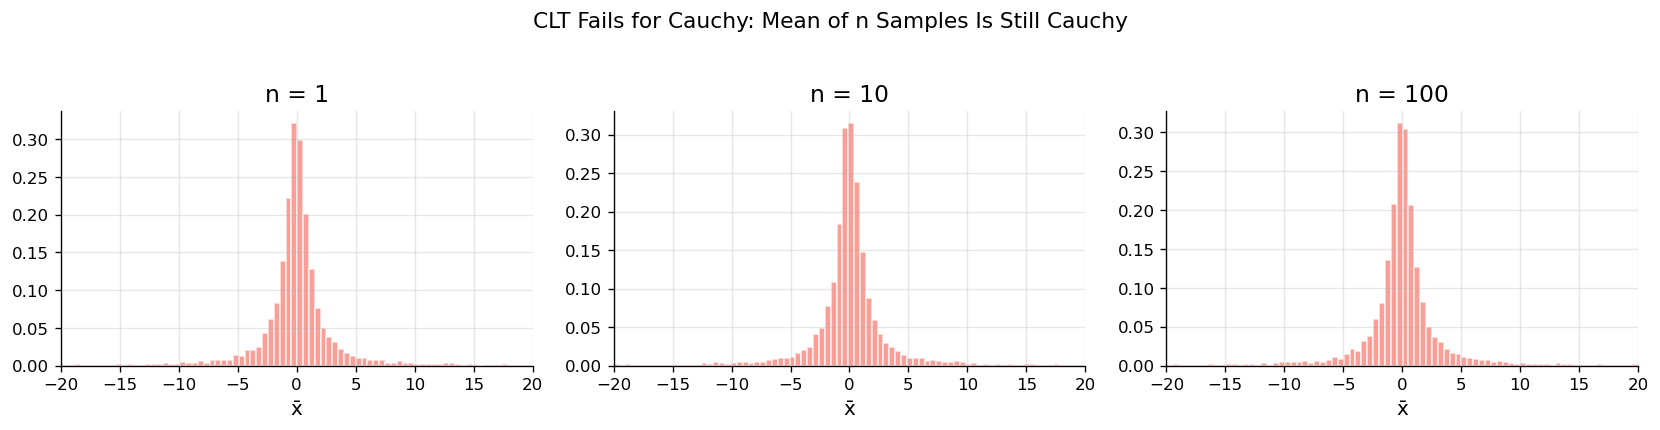

In [7]:
# CLT failure: Cauchy distribution (infinite variance)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for i, n in enumerate([1, 10, 100]):
    means = np.array([rng.standard_cauchy(n).mean() for _ in range(10_000)])
    # Clip extreme values for plotting
    means_clipped = means[(means > -20) & (means < 20)]
    axes[i].hist(means_clipped, bins=80, density=True, alpha=0.7, edgecolor="white")
    axes[i].set_title(f"n = {n}")
    axes[i].set_xlim(-20, 20)
    axes[i].set_xlabel("x̄")

plt.suptitle(
    "CLT Fails for Cauchy: Mean of n Samples Is Still Cauchy", fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

The shape doesn't change at all — the average of $n$ Cauchy samples is *still Cauchy*. The heavy tails (infinite variance) prevent the CLT from applying. This is why the finite-variance condition matters.

---

## 7. How Large Must $n$ Be?

The CLT is asymptotic — it says "as $n \to \infty$". In practice, how large is "large enough"?

**Rules of thumb:**
- **Symmetric distributions** (Uniform, already-Normal): $n \geq 5$ is often sufficient.
- **Mildly skewed** (Exponential, Binomial with $p$ not extreme): $n \geq 30$ works well.
- **Heavily skewed** (Exponential with small rate, Binomial with $p$ near 0 or 1): may need $n \geq 100$.

The real answer: **check with a simulation**. The CLT is a theoretical guarantee, but the rate of convergence depends on the parent distribution's shape.

---

## Exercises

**Exercise 3.1 (CLT simulation).** Draw 10,000 sample means of size $n = 50$ from a $\text{Poisson}(\lambda = 3)$ distribution. Plot the histogram and overlay the theoretical Normal PDF. How well does it fit?

**Exercise 3.2 (Normal approximation).** A factory produces items with a 5% defect rate. In a batch of 200 items, use the CLT to approximate $P(\text{more than 15 defects})$. Compare with the exact Binomial answer.

**Exercise 3.3 (Sample size).** For $X \sim \text{Exponential}(\lambda = 1)$, how large must $n$ be so that the CLT approximation of $P(|\bar{X}_n - 1| > 0.1)$ is within 1% of the true (simulated) value?

**Exercise 3.4 (Sum vs. mean).** The CLT applies to both the **sum** $S_n = \sum X_i$ and the **mean** $\bar{X}_n = S_n / n$. Write the approximate Normal distribution for $S_n$ and verify with a simulation for $X_i \sim \text{Bernoulli}(0.4)$, $n = 50$.

**Exercise 3.5 (Challenge — Berry-Esseen).** The Berry-Esseen theorem gives a bound on the CLT approximation error: $|F_n(x) - \Phi(x)| \leq C \cdot \rho / (\sigma^3 \sqrt{n})$ where $\rho = E[|X - \mu|^3]$. For $X \sim \text{Bernoulli}(0.5)$, compute $\rho$ and estimate how large $n$ must be for the bound to be $\leq 0.01$.

---

## Key Takeaways

1. The **Central Limit Theorem**: the standardised sample mean of i.i.d. RVs with finite variance converges in distribution to $\mathcal{N}(0, 1)$.
2. The CLT explains **why the Normal distribution is ubiquitous** — any quantity that arises as the average of many independent contributions will be approximately Normal.
3. The **Normal approximation to the Binomial** ($X \approx \mathcal{N}(np, np(1-p))$ for large $n$) is a direct consequence.
4. The CLT requires **finite variance** — it fails for heavy-tailed distributions like the Cauchy.
5. The **rate of convergence** depends on the skewness of the parent distribution. Rule of thumb: $n \geq 30$ for most practical cases.

**Next:** [04 — Monte Carlo Sampling](04_monte_carlo_sampling.ipynb) — How to generate random samples from arbitrary distributions: the inverse transform, acceptance-rejection, and importance sampling.

In [8]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/BetaPDFMorph@2026-03-21@21-14-24.gif
  ✓ media/gifs/BinomialPMFMorph@2026-03-19@15-56-51.gif
  ✓ media/gifs/CLTConvergence@2026-03-19@15-50-56.gif
  Cleaned up local temp render files (kept media/jupyter/).
